In [1]:
# ================= CELL 1: Install dependencies =================
!pip install -q tensorflow opencv-python-headless scikit-learn matplotlib pandas reportlab kagglehub streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 128.8 MB/s eta 0:00:00


In [2]:
# ================= CELL 2: Imports =================
import os
import cv2
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import kagglehub

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# ================= CELL 3: Project structure =================
BASE_DIR = "/content/defect_detection_project"
DIRS = ["dataset", "models", "outputs", "reports", "gradcam", "streamlit_app"]

for d in DIRS:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
GRADCAM_DIR = os.path.join(BASE_DIR, "gradcam")
STREAMLIT_DIR = os.path.join(BASE_DIR, "streamlit_app")

print("Project structure created at:", BASE_DIR)


Project structure created at: /content/defect_detection_project


In [4]:
# ================= CELL 4: Download NEU Surface Defect Dataset =================
download_path = kagghub_path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
print("Dataset downloaded to:", download_path)

def find_class_dirs(root):
    class_dirs = {}
    for dirpath, dirnames, filenames in os.walk(root):
        images = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
        if images:
            class_name = os.path.basename(dirpath)
            class_dirs.setdefault(class_name, [])
            class_dirs[class_name].extend([os.path.join(dirpath, f) for f in images])
    return class_dirs

raw_class_dirs = find_class_dirs(download_path)
print("Classes found:", list(raw_class_dirs.keys()))
print("Total images:", sum(len(v) for v in raw_class_dirs.values()))

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Dataset downloaded to: /kaggle/input/neu-surface-defect-database
Classes found: ['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']
Total images: 1800


In [5]:
# ================= CELL 5: Organize dataset into train/val/test =================
from sklearn.model_selection import train_test_split

SPLIT_DIR = os.path.join(DATASET_DIR, "split")
for split in ["train", "val", "test"]:
    for class_name in raw_class_dirs.keys():
        os.makedirs(os.path.join(SPLIT_DIR, split, class_name), exist_ok=True)

for class_name, filepaths in raw_class_dirs.items():
    train_files, temp_files = train_test_split(filepaths, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    for f in train_files:
        shutil.copy(f, os.path.join(SPLIT_DIR, "train", class_name, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(SPLIT_DIR, "val", class_name, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(SPLIT_DIR, "test", class_name, os.path.basename(f)))

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

print("Dataset split completed.")

Dataset split completed.


                 Train  Validation  Test
crazing            210          45    45
inclusion          210          45    45
patches            210          45    45
pitted_surface     210          45    45
rolled-in_scale    210          45    45
scratches          210          45    45


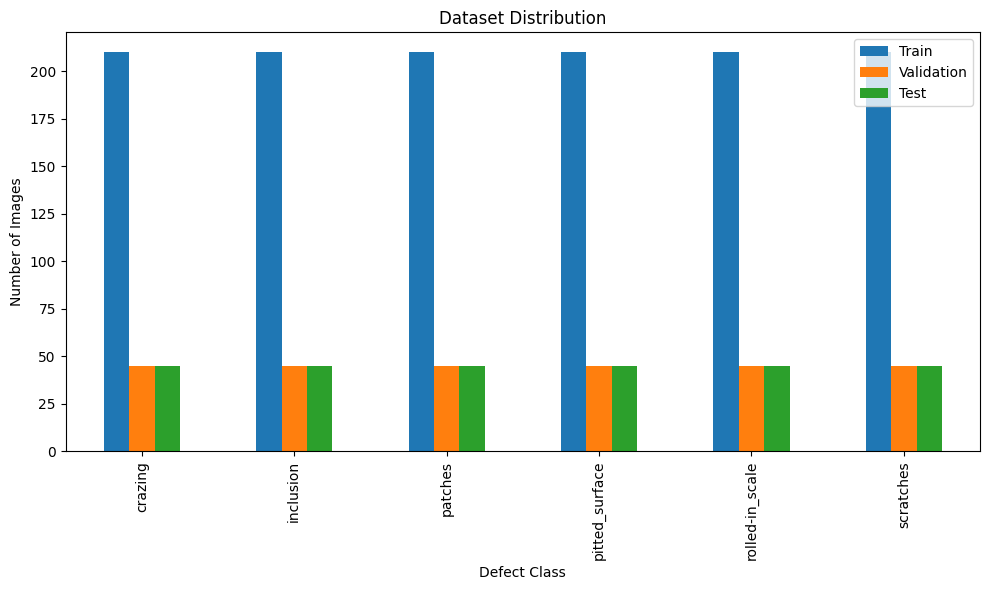

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [6]:
# ================= CELL 6: Dataset statistics =================
def dataset_stats(directory):
    stats = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            stats[class_name] = len(os.listdir(class_path))
    return stats

train_stats = dataset_stats(TRAIN_DIR)
val_stats = dataset_stats(VAL_DIR)
test_stats = dataset_stats(TEST_DIR)

stats_df = pd.DataFrame({"Train": train_stats, "Validation": val_stats, "Test": test_stats}).fillna(0).astype(int)
print(stats_df)

stats_df.plot(kind="bar", figsize=(10, 6))
plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Defect Class")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "dataset_distribution.png"))
plt.show()

CLASS_NAMES = sorted(train_stats.keys())
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

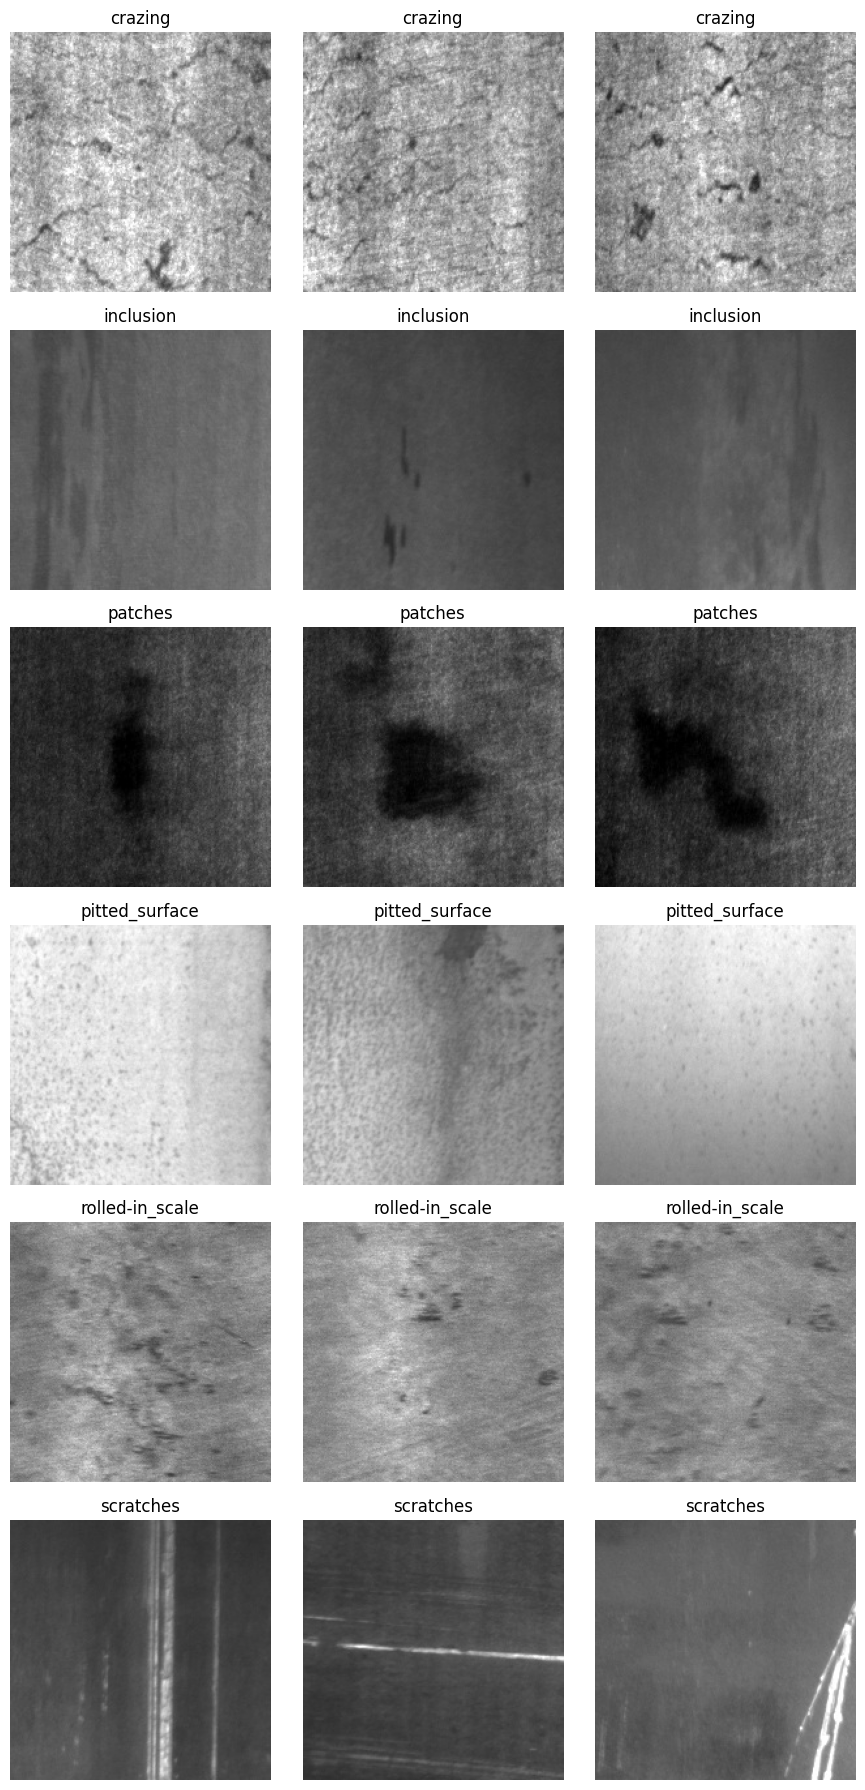

In [7]:
# ================= CELL 7: Sample images =================
def show_sample_images(directory, class_names, samples_per_class=3):
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(samples_per_class * 3, len(class_names) * 3))
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        image_files = os.listdir(class_path)[:samples_per_class]
        for j, img_file in enumerate(image_files):
            img = cv2.imread(os.path.join(class_path, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax = axes[i, j] if len(class_names) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(class_name)
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, "sample_images.png"))
    plt.show()

show_sample_images(TRAIN_DIR, CLASS_NAMES)

In [8]:
# ================= CELL 8: Data generators =================
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=True, seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=False
)

with open(os.path.join(MODELS_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f)

Found 1260 images belonging to 6 classes.
Found 270 images belonging to 6 classes.
Found 270 images belonging to 6 classes.


In [9]:
with open(os.path.join(MODELS_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f)

In [10]:
# ================= CELL 9: Build transfer learning model =================
def build_model(num_classes, img_size=224):
    base_model = EfficientNetB0(
        include_top=False, weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES, IMG_SIZE)
model.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# ================= CELL 10: Callbacks =================
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "best_model.h5")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7),
    ModelCheckpoint(BEST_MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1)
]

In [12]:
# ================= CELL 11: Initial training (frozen base) =================
INITIAL_EPOCHS = 15

history_initial = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6377 - loss: 1.0060
Epoch 1: val_accuracy improved from None to 0.96667, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 1: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7905 - loss: 0.6093 - val_accuracy: 0.9667 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9280 - loss: 0.1849
Epoch 2: val_accuracy did not improve from 0.96667
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9524 - loss: 0.1392 - val_accuracy: 0.9667 - val_loss: 0.1158 - learning_rate: 0.0010
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9766 - loss: 0.1043
Epoch 3: val_accuracy did not improve from 0.96667
40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9722 - loss: 0.1061 - val_accuracy: 0.9667 - val_loss: 0.1081 - learning_rate: 0.0010
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9739 - loss: 0.0981
Epoch 4: val_accuracy improved from 0.96667 to 0.97037, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 4: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9738 - loss: 0.0919 - val_accuracy: 0.9704 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9819 - loss: 0.0749
Epoch 5: val_accuracy improved from 0.97037 to 0.97407, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 5: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9810 - loss: 0.0721 - val_accuracy: 0.9741 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9677 - loss: 0.0848
Epoch 6: val_accuracy improved from 0.97407 to 0.97778, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 6: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9738 - loss: 0.0749 - val_accuracy: 0.9778 - val_loss: 0.0700 - learning_rate: 0.0010
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9796 - loss: 0.0703
Epoch 7: val_accuracy did not improve from 0.97778
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9802 - loss: 0.0683 - val_accuracy: 0.9778 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9875 - loss: 0.0534
Epoch 8: val_accuracy did not improve from 0.97778
40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9786 - loss: 0.0660 - val_accuracy: 0.9741 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9796 - loss: 0.0591
Epoch 9: val_accuracy improved from 0.97778 to 0.98889, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 9: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.9889 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 10/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9816 - loss: 0.0495
Epoch 10: val_accuracy did not improve from 0.98889
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9825 - loss: 0.0507 - val_accuracy: 0.9889 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 11/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9873 - loss: 0.0394
Epoch 11: val_accuracy did not improve from 0.98889
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9857 - loss: 0.0432 - val_accuracy: 0.9815 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 12/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9766 - loss: 0.0713
Epoch 12: val_accuracy did not improve from 0.98889
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9825 - loss: 0.0589 - val_accura

In [13]:
# ================= CELL 12: Fine-tuning =================
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

FINE_TUNE_EPOCHS = 15

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
)
model = load_model(BEST_MODEL_PATH)
_ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8713 - loss: 0.3938
Epoch 1: val_accuracy did not improve from 0.98889
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8929 - loss: 0.3546 - val_accuracy: 0.9889 - val_loss: 0.0386 - learning_rate: 1.0000e-05
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9304 - loss: 0.2604
Epoch 2: val_accuracy improved from 0.98889 to 0.99259, saving model to /content/defect_detection_project/models/best_model.h5



Epoch 2: finished saving model to /content/defect_detection_project/models/best_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9325 - loss: 0.2550 - val_accuracy: 0.9926 - val_loss: 0.0475 - learning_rate: 1.0000e-05
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9381 - loss: 0.2292
Epoch 3: val_accuracy did not improve from 0.99259
40/40 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9389 - loss: 0.2261 - val_accuracy: 0.9889 - val_loss: 0.0602 - learning_rate: 1.0000e-05
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9539 - loss: 0.1752
Epoch 4: val_accuracy did not improve from 0.99259
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9548 - loss: 0.1713 - val_accuracy: 0.9778 - val_loss: 0.0732 - learning_rate: 1.0000e-05
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9425 - loss: 0.2187
Epoch 5: val_accuracy did not improve from 0.99259
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9524 - loss: 0.1784 - val_

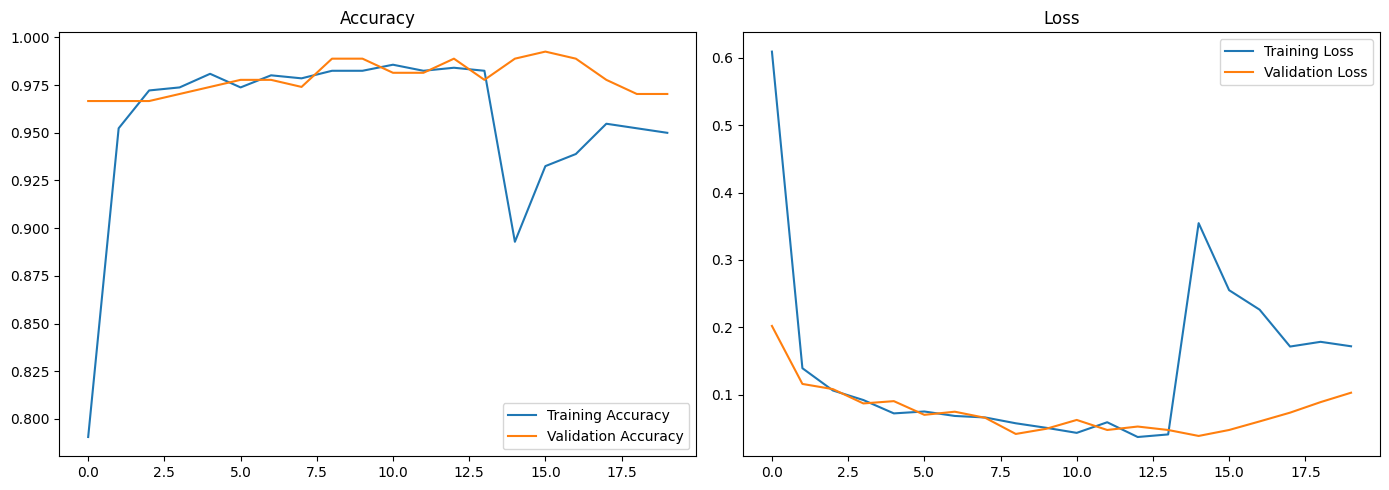

In [14]:
# ================= CELL 13: Training curves =================
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history_initial, history_finetune, "accuracy")
val_acc = combine_history(history_initial, history_finetune, "val_accuracy")
loss = combine_history(history_initial, history_finetune, "loss")
val_loss = combine_history(history_initial, history_finetune, "val_loss")

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "training_curves.png"))
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Accuracy: 0.9556
Precision: 0.9601
Recall: 0.9556
F1 Score: 0.9557


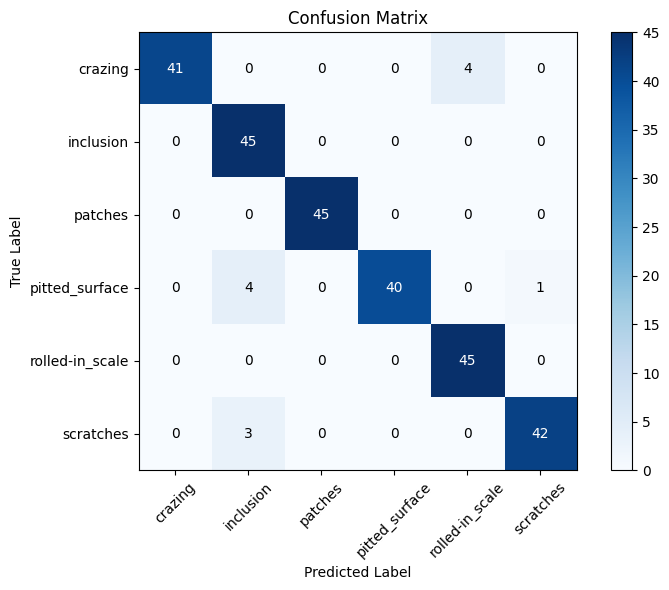

                 precision    recall  f1-score   support

        crazing       1.00      0.91      0.95        45
      inclusion       0.87      1.00      0.93        45
        patches       1.00      1.00      1.00        45
 pitted_surface       1.00      0.89      0.94        45
rolled-in_scale       0.92      1.00      0.96        45
      scratches       0.98      0.93      0.95        45

       accuracy                           0.96       270
      macro avg       0.96      0.96      0.96       270
   weighted avg       0.96      0.96      0.96       270



In [15]:
# ================= CELL 14: Evaluation =================
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "confusion_matrix.png"))
plt.show()

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

with open(os.path.join(OUTPUTS_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

In [16]:
# ================= CELL 15: Grad-CAM implementation (single connected graph) =================
from tensorflow.keras.layers import Conv2D, InputLayer

def get_last_conv_layer_name(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

LAST_CONV_LAYER = get_last_conv_layer_name(base_model)

# Rebuild head on top of base_model's own graph, using the SAME head layers/weights from `model`
last_conv_output = base_model.get_layer(LAST_CONV_LAYER).output
base_output = base_model.output

head_layers = [l for l in model.layers if l.name != base_model.name and not isinstance(l, InputLayer)]

x = base_output
for layer in head_layers:
    x = layer(x)

grad_model = Model(inputs=base_model.input, outputs=[last_conv_output, x])

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), int(pred_index.numpy()) if hasattr(pred_index, "numpy") else int(pred_index)

def overlay_gradcam(img_path, heatmap, alpha=0.4, img_size=224):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_colored, overlay

In [17]:
# ================= CELL 16: Prediction module =================
def load_and_preprocess_image(img_path, img_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_array = preprocess_input(np.expand_dims(img_resized.astype(np.float32), axis=0))
    return img_array

def predict_defect(img_path, model, class_names, img_size=224):
    img_array = load_and_preprocess_image(img_path, img_size)
    _, predictions_tensor = grad_model(img_array)
    predictions = predictions_tensor.numpy()[0]

    top_indices = np.argsort(predictions)[::-1][:3]
    top_predictions = [(class_names[i], float(predictions[i])) for i in top_indices]

    predicted_class = class_names[top_indices[0]]
    confidence = float(predictions[top_indices[0]])

    heatmap, pred_index = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER, pred_index=int(top_indices[0]))
    original, heatmap_colored, overlay = overlay_gradcam(img_path, heatmap, img_size=img_size)

    gradcam_path = os.path.join(GRADCAM_DIR, "gradcam_overlay.png")
    cv2.imwrite(gradcam_path, overlay)

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top_predictions": top_predictions,
        "original": original,
        "heatmap": heatmap_colored,
        "overlay": overlay,
        "gradcam_path": gradcam_path
    }

Saving defect2.jpg to defect2.jpg
Predicted Defect: inclusion
Confidence Score: 99.98%
Top 3 Predictions:
  inclusion: 99.98%
  pitted_surface: 0.01%
  scratches: 0.01%


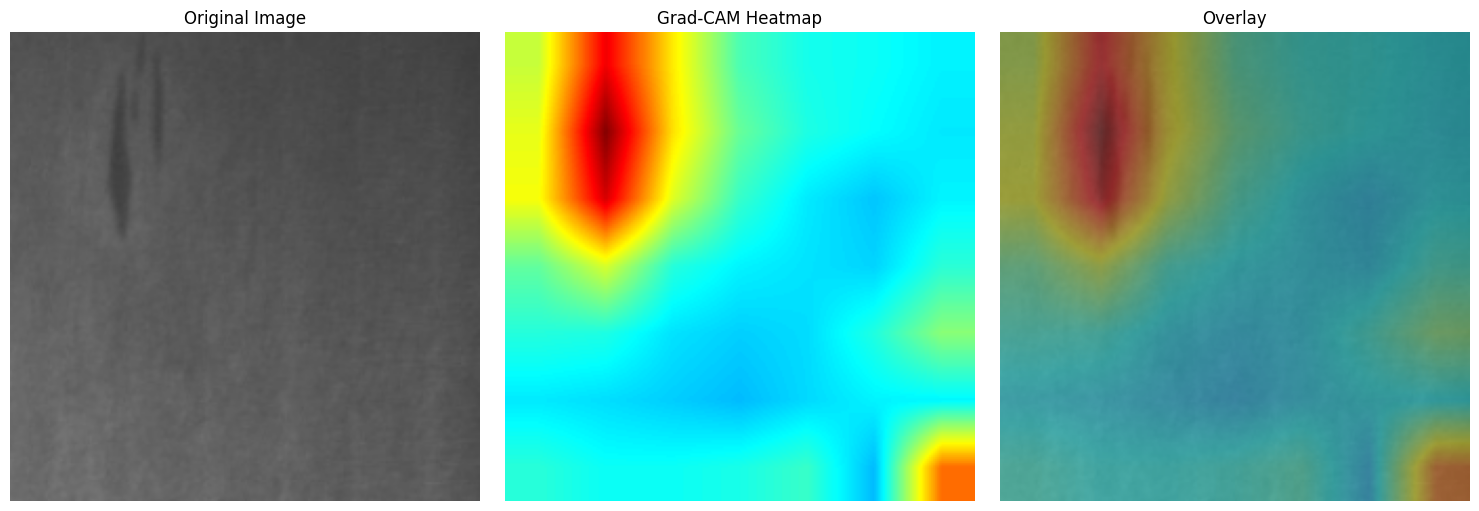

In [18]:
# ================= CELL 17: Run prediction and display =================
from google.colab import files

uploaded = files.upload()
sample_image_path = list(uploaded.keys())[0]
shutil.copy(sample_image_path, os.path.join(OUTPUTS_DIR, sample_image_path))

result = predict_defect(sample_image_path, model, CLASS_NAMES, IMG_SIZE)

print("Predicted Defect:", result["predicted_class"])
print("Confidence Score: {:.2f}%".format(result["confidence"] * 100))
print("Top 3 Predictions:")
for cls, prob in result["top_predictions"]:
    print(f"  {cls}: {prob*100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(result["original"], cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(result["heatmap"], cv2.COLOR_BGR2RGB))
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(result["overlay"], cv2.COLOR_BGR2RGB))
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "gradcam_result.png"))
plt.show()

In [19]:
# ================= CELL 18: PDF report generation =================
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

def generate_pdf_report(result, sample_image_path, report_path):
    doc = SimpleDocTemplate(report_path, pagesize=A4)
    styles = getSampleStyleSheet()
    elements = []

    # --- POINT 4: Title + one-line project description ---
    elements.append(Paragraph("Manufacturing Defect Detection Report", styles["Title"]))
    elements.append(Paragraph("Automated surface defect classification using a fine-tuned EfficientNetB0 CNN, with Grad-CAM explainability.", styles["Normal"]))
    elements.append(Spacer(1, 20))

    elements.append(Paragraph(f"Predicted Class: {result['predicted_class']}", styles["Heading2"]))
    elements.append(Paragraph(f"Confidence Score: {result['confidence']*100:.2f}%", styles["Normal"]))
    elements.append(Spacer(1, 15))

    # --- POINT 3: Clean class names in the table ---
    table_data = [["Class", "Probability (%)"]]
    for cls, prob in result["top_predictions"]:
        cls_clean = cls.replace("_", " ").replace("-", " ").title()
        table_data.append([cls_clean, f"{prob*100:.2f}"])

    table = Table(table_data, colWidths=[250, 150])
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2C3E50")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ALIGN", (0, 0), (-1, -1), "CENTER")
    ]))
    elements.append(table)
    elements.append(Spacer(1, 20))

    # --- POINT 1 + POINT 2: Side-by-side images with Grad-CAM caption ---
    elements.append(Paragraph("Uploaded Image & Grad-CAM Visualization", styles["Heading2"]))
    elements.append(Paragraph("🔴🟡Red/Yellow = high model attention (defect area) | 🔵🟢Blue/Green = low attention (background) ", styles["Normal"]))
    elements.append(Spacer(1, 10))

    img_table = Table([[
        RLImage(sample_image_path, width=2.5*inch, height=2.5*inch),
        RLImage(result["gradcam_path"], width=2.5*inch, height=2.5*inch)
    ]])
    elements.append(img_table)

    doc.build(elements)

In [20]:
# ================= CELL 19: Streamlit app file =================
streamlit_code = '''
import streamlit as st
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Conv2D, InputLayer
from tensorflow.keras.applications.efficientnet import preprocess_input
import json
import os
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

st.set_page_config(page_title="Manufacturing Defect Detection", page_icon="🏭", layout="wide")

MODEL_PATH = "models/best_model.h5"
CLASS_INDICES_PATH = "models/class_indices.json"
IMG_SIZE = 224

@st.cache_resource
def load_defect_model():
    model = load_model(MODEL_PATH)
    with open(CLASS_INDICES_PATH, "r") as f:
        class_indices = json.load(f)
    class_names = sorted(class_indices, key=class_indices.get)

    base_model = model.layers[1]

    def get_last_conv_layer_name(base_model):
        for layer in reversed(base_model.layers):
            if isinstance(layer, Conv2D):
                return layer.name
        raise ValueError("No Conv2D layer found.")

    last_conv_layer_name = get_last_conv_layer_name(base_model)

    last_conv_output = base_model.get_layer(last_conv_layer_name).output
    base_output = base_model.output
    head_layers = [l for l in model.layers if l.name != base_model.name and not isinstance(l, InputLayer)]

    x = base_output
    for layer in head_layers:
        x = layer(x)

    grad_model = Model(inputs=base_model.input, outputs=[last_conv_output, x])

    return model, class_names, grad_model

model, class_names, grad_model = load_defect_model()

def make_gradcam_heatmap(img_array, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_gradcam(img_rgb, heatmap, alpha=0.4, img_size=224):
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_resized, 1 - alpha, heatmap_colored_rgb, alpha, 0)
    return img_resized, heatmap_colored_rgb, overlay

def generate_pdf_report(pred_class, confidence, top_preds, img_path, gradcam_path, report_path):
    doc = SimpleDocTemplate(report_path, pagesize=A4)
    styles = getSampleStyleSheet()
    elements = []

    elements.append(Paragraph("Manufacturing Defect Detection Report", styles["Title"]))
    elements.append(Paragraph("Automated surface defect classification using a fine-tuned EfficientNetB0 CNN, with Grad-CAM explainability.", styles["Normal"]))
    elements.append(Spacer(1, 20))

    elements.append(Paragraph(f"Predicted Class: {pred_class}", styles["Heading2"]))
    elements.append(Paragraph(f"Confidence Score: {confidence*100:.2f}%", styles["Normal"]))
    elements.append(Spacer(1, 15))

    table_data = [["Class", "Probability (%)"]]
    for cls, prob in top_preds:
        cls_clean = cls.replace("_", " ").replace("-", " ").title()
        table_data.append([cls_clean, f"{prob*100:.2f}"])

    table = Table(table_data, colWidths=[250, 150])
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2C3E50")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ALIGN", (0, 0), (-1, -1), "CENTER")
    ]))
    elements.append(table)
    elements.append(Spacer(1, 20))

    elements.append(Paragraph("Uploaded Image & Grad-CAM Visualization", styles["Heading2"]))
    elements.append(Paragraph("Red/warm areas show where the model focused most to make its prediction.", styles["Normal"]))
    elements.append(Spacer(1, 10))

    img_table = Table([[
        RLImage(img_path, width=2.5*inch, height=2.5*inch),
        RLImage(gradcam_path, width=2.5*inch, height=2.5*inch)
    ]])
    elements.append(img_table)

    doc.build(elements)

st.title("🏭 Manufacturing Defect Detection")
st.write("Upload a product image to detect surface defects using a fine-tuned EfficientNetB0 model.")

uploaded_file = st.file_uploader("Upload Product Image", type=["jpg", "jpeg", "png", "bmp"])

if uploaded_file is not None:
    os.makedirs("outputs", exist_ok=True)
    os.makedirs("gradcam", exist_ok=True)
    os.makedirs("reports", exist_ok=True)

    img_path = os.path.join("outputs", uploaded_file.name)
    with open(img_path, "wb") as f:
        f.write(uploaded_file.getbuffer())

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if st.button("Predict"):
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_array = preprocess_input(np.expand_dims(img_resized.astype(np.float32), axis=0))

        _, predictions_tensor = grad_model(img_array)
        predictions = predictions_tensor.numpy()[0]
        top_indices = np.argsort(predictions)[::-1][:3]
        top_preds = [(class_names[i], float(predictions[i])) for i in top_indices]
        pred_class = class_names[top_indices[0]]
        confidence = float(predictions[top_indices[0]])

        heatmap = make_gradcam_heatmap(img_array, pred_index=int(top_indices[0]))
        original, heatmap_colored, overlay = overlay_gradcam(img_rgb, heatmap, img_size=IMG_SIZE)

        gradcam_path = os.path.join("gradcam", "gradcam_overlay.png")
        cv2.imwrite(gradcam_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        col1, col2 = st.columns(2)

        with col1:
            st.subheader("Prediction Card")
            st.success(f"Predicted Defect: {pred_class}")
            st.metric("Confidence Score", f"{confidence*100:.2f}%")
            st.write("Top 3 Predictions")
            for cls, prob in top_preds:
                st.write(f"{cls}: {prob*100:.2f}%")

        with col2:
            st.subheader("Original Image")
            st.image(original, width=350)

        st.subheader("Grad-CAM Visualization")
        st.caption("🔴🟡Red/Yellow = high model attention (defect area) | 🔵🟢Blue/Green = low attention (background)")
        gc1, gc2 = st.columns(2)
        with gc1:
            st.image(heatmap_colored, caption="Heatmap", width=350)
        with gc2:
            st.image(overlay, caption="Overlay", width=350)

        report_path = os.path.join("reports", "defect_detection_report.pdf")
        generate_pdf_report(pred_class, confidence, top_preds, img_path, gradcam_path, report_path)

        with open(report_path, "rb") as f:
            st.download_button("Download PDF Report", f, file_name="defect_detection_report.pdf", mime="application/pdf")
'''

with open(os.path.join(STREAMLIT_DIR, "app.py"), "w") as f:
    f.write(streamlit_code)

print("Streamlit app saved at:", os.path.join(STREAMLIT_DIR, "app.py"))

Streamlit app saved at: /content/defect_detection_project/streamlit_app/app.py


In [21]:
# ================= CELL 20: Copy model and assets for Streamlit deployment =================
dest_path = os.path.join(STREAMLIT_DIR, "..", "models", "best_model.h5")

if os.path.abspath(BEST_MODEL_PATH) != os.path.abspath(dest_path):
    shutil.copy(BEST_MODEL_PATH, dest_path)
else:
    print("Model already in place, skipping copy.")

for folder in ["models", "outputs", "gradcam", "reports"]:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("All assets ready for Streamlit deployment.")

Model already in place, skipping copy.
All assets ready for Streamlit deployment.


In [22]:
# ================= CELL 21: Launch Streamlit app via ngrok =================
from pyngrok import ngrok

ngrok.set_auth_token("3GWFxaBo9Rnr84EACpxvb9tIBdn_5RL6wQvkZbVj69DuAUNQC")
ngrok.kill()

os.chdir(BASE_DIR)
get_ipython().system_raw(f'streamlit run streamlit_app/app.py --server.port 8501 &')
public_url = ngrok.connect(8501)
print("Streamlit app running at:", public_url)

Streamlit app running at: NgrokTunnel: "https://wireless-barbed-carnival.ngrok-free.dev" -> "http://localhost:8501"


In [24]:
from google.colab import files

# 1. Download app.py
files.download(os.path.join(STREAMLIT_DIR, "app.py"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

# 2. Download best_model.h5 (~31MB, will take a bit longer)
files.download(os.path.join(MODELS_DIR, "best_model.h5"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files

# 3. Download class_indices.json
files.download(os.path.join(MODELS_DIR, "class_indices.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>